In [6]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx # For background maps



In [7]:
def analyze_pypsa_vre_nodes(csv_dir='./Network_CSV'):
    """
    Analyzes VRE capacity factors and load correlations directly from PyPSA CSV exports.
    Explicitly handles integer-based snapshot indices by converting them to 3-hourly DatetimeIndices.
    """
    # 1. Define file paths
    cf_csv_path = os.path.join(csv_dir, 'generators-p_max_pu.csv')
    load_csv_path = os.path.join(csv_dir, 'loads-p_set.csv')
    
    # 2. Load Data (Without parse_dates to handle the raw integers safely)
    df_cf = pd.read_csv(cf_csv_path, index_col=0)
    df_load = pd.read_csv(load_csv_path, index_col=0)
    
    # 3. Reconstruct the DatetimeIndex
    # This overwrites the 0, 1, 2... index with a proper timestamp starting Jan 1st
    # '3h' frequency automatically steps forward by 3 hours per row.
    df_cf.index = pd.date_range(start='2026-01-01', periods=len(df_cf), freq='3h')
    df_load.index = pd.date_range(start='2026-01-01', periods=len(df_load), freq='3h')
    
    # Calculate total system load at each time step
    total_system_load = df_load.sum(axis=1)
    
    # Separate columns by technology
    solar_cols = [c for c in df_cf.columns if 'solar' in c.lower()]
    wind_cols = [c for c in df_cf.columns if 'onwind' in c.lower() or 'wind' in c.lower()]
    
    # 4. Define Statistical Function
    def calculate_core_stats(data_subset, system_load):
        stats = pd.DataFrame(index=data_subset.columns)
        stats['Mean_CF'] = data_subset.mean()
        stats['Std_Dev'] = data_subset.std()
        
        # Coefficient of Variation: Variability relative to the mean
        stats['CoV'] = stats['Std_Dev'] / stats['Mean_CF'] 
        
        # P90: The capacity factor exceeded 10% of the time (high-performance threshold)
        stats['P90'] = data_subset.quantile(0.90)          
        
        # Pearson correlation between node CF and total system demand
        stats['Load_Correlation'] = data_subset.corrwith(system_load)
        
        return stats

    # 5. Calculate Core Statistics
    solar_stats = calculate_core_stats(df_cf[solar_cols], total_system_load)
    wind_stats = calculate_core_stats(df_cf[wind_cols], total_system_load)
    
    # 6. Temporal Profiling (Diurnal and Seasonal)
    # The .hour and .month attributes will now work perfectly
    solar_diurnal = df_cf[solar_cols].groupby(df_cf.index.hour).mean()
    wind_diurnal = df_cf[wind_cols].groupby(df_cf.index.hour).mean()
    
    solar_seasonal = df_cf[solar_cols].groupby(df_cf.index.month).mean()
    wind_seasonal = df_cf[wind_cols].groupby(df_cf.index.month).mean()

    # 7. Compile and Return Results
    results = {
        'solar_stats': solar_stats.sort_values(by='Mean_CF', ascending=False),
        'wind_stats': wind_stats.sort_values(by='Mean_CF', ascending=False),
        'solar_diurnal': solar_diurnal,
        'wind_diurnal': wind_diurnal,
        'solar_seasonal': solar_seasonal,
        'wind_seasonal': wind_seasonal
    }
    
    return results



In [8]:


# --- Setup and Data Loading ---

def load_spatial_data(csv_dir='./Network_CSV'):
    """Loads bus coordinates from PyPSA exports."""
    buses_path = os.path.join(csv_dir, 'buses.csv')
    df_buses = pd.read_csv(buses_path, index_col=0)
    return df_buses[['x', 'y']] # Extract longitude (x) and latitude (y)

# Assuming `analysis_results` is the output from the previous script
# For demonstration, we will recreate a dummy version if it doesn't exist
# In your actual workflow, pass the results from the previous step.
# analysis_results = analyze_pypsa_vre_nodes('./Network_CSV')

# --- 1. Spatial Map (Chloropleth/Bubble Map) ---

def plot_spatial_map(stats_df, buses_df, title, tech, output_filename=None):
    """Plots a map of nodes colored/sized by Mean CF."""
    print(f"Generating Spatial Map for {tech}...")
    
    # Merge CF stats with coordinates based on node name
    # We need to extract the bus name from the generator name (e.g., 'KEO 0 solar' -> 'KEO 0')
    stats_df['Bus'] = stats_df.index.str.replace(f' {tech}', '', regex=False)
    merged_data = stats_df.merge(buses_df, left_on='Bus', right_index=True)
    
    # Convert to GeoDataFrame
    geometry = [Point(xy) for xy in zip(merged_data.x, merged_data.y)]
    gdf = gpd.GeoDataFrame(merged_data, geometry=geometry, crs="EPSG:4326")
    
    # Reproject for accurate plotting with contextily (Web Mercator)
    gdf = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot points: Size by CF, Color by CF
    scatter = gdf.plot(ax=ax, column='Mean_CF', cmap='viridis' if tech=='solar' else 'plasma',
                       markersize=gdf['Mean_CF'] * 500, # Adjust scale as needed
                       legend=True, legend_kwds={'label': "Mean Capacity Factor"},
                       alpha=0.8, edgecolor='k')

    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    # Add labels
    for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['Bus']):
        ax.text(x, y, label, fontsize=8, ha='right')

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    if output_filename:
        plt.savefig(output_filename, dpi=300)
    plt.show()

# --- 2. Ranked Bar Charts ---

def plot_ranked_bar_chart(stats_df, title, output_filename=None):
    """Plots a bar chart of nodes ranked by Mean CF."""
    print(f"Generating Ranked Bar Chart: {title}...")
    
    # Sort data
    sorted_df = stats_df.sort_values(by='Mean_CF', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=sorted_df.index, y=sorted_df['Mean_CF'], palette='mako')
    
    plt.title(title, fontsize=14)
    plt.ylabel('Mean Capacity Factor', fontsize=12)
    plt.xlabel('Node', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on top of bars
    for i, v in enumerate(sorted_df['Mean_CF']):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
        
    plt.tight_layout()
    if output_filename:
        plt.savefig(output_filename, dpi=300)
    plt.show()

# --- 3. Temporal Heatmaps (Month vs. Hour) ---

# --- 3. Temporal Heatmaps (Month vs. Hour) ---

def plot_temporal_heatmap(raw_df, node_name, output_filename=None):
    """Plots a heatmap of Mean CF by Month and Hour for a specific node."""
    print(f"Generating Heatmap for {node_name}...")
    
    # Extract data for the specific node
    node_data = raw_df[[node_name]].copy()
    
    # --- THE FIX ---
    # Check if the index is a proper DatetimeIndex. If not, forcefully reconstruct it.
    if not isinstance(node_data.index, pd.DatetimeIndex):
        print(f"  -> Converting integer index to 3-hourly DatetimeIndex for {node_name}...")
        node_data.index = pd.date_range(start='2026-01-01', periods=len(node_data), freq='3h')
    # ---------------
    
    node_data['Month'] = node_data.index.month
    node_data['Hour'] = node_data.index.hour
    
    # Pivot table for heatmap (Mean CF per month-hour combination)
    pivot_table = node_data.pivot_table(values=node_name, index='Hour', columns='Month', aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Mean Capacity Factor'})
    
    plt.title(f'Temporal Profile (Month vs Hour): {node_name}', fontsize=14)
    plt.ylabel('Hour of Day', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.gca().invert_yaxis() # Put hour 0 at top
    
    plt.tight_layout()
    if output_filename:
        plt.savefig(output_filename, dpi=300)
    plt.show()

# --- 4. Duration Curves ---

def plot_duration_curves(raw_df, tech_cols, title, output_filename=None):
    """Plots sorted annual duration curves for a set of nodes."""
    print(f"Generating Duration Curves: {title}...")
    
    plt.figure(figsize=(12, 8))
    
    for col in tech_cols:
        # Sort values descending
        sorted_vals = np.sort(raw_df[col].dropna())[::-1]
        # X-axis is the fraction of the year (or just rank)
        x_vals = np.arange(len(sorted_vals)) / len(sorted_vals) * 100 
        
        plt.plot(x_vals, sorted_vals, label=col, alpha=0.7)

    plt.title(title, fontsize=14)
    plt.ylabel('Capacity Factor', fontsize=12)
    plt.xlabel('Percentage of Time Exceeded (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Put legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
    
    plt.tight_layout()
    if output_filename:
        plt.savefig(output_filename, dpi=300)
    plt.show()

# --- 5. Correlation Matrix ---

def plot_correlation_matrix(raw_df, tech_cols, title, output_filename=None):
    """Plots a heatmap of the correlation matrix between nodes."""
    print(f"Generating Correlation Matrix: {title}...")
    
    # Calculate correlation matrix
    corr_matrix = raw_df[tech_cols].corr()
    
    plt.figure(figsize=(10, 8))
    # Use a diverging colormap centered at 0 or 0.5 depending on expected range
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f",
                square=True, cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    if output_filename:
        plt.savefig(output_filename, dpi=300)
    plt.show()

# --- Main Execution ---
# Note: You will need to integrate this with the data loaded in the previous step.
# Assuming you have `analysis_results` and `df_cf` (raw data) available.


In [9]:
csv_dir='./Network_CSV'


cf_csv_path = os.path.join(csv_dir, 'generators-p_max_pu.csv')
load_csv_path = os.path.join(csv_dir, 'loads-p_set.csv')
    
    # 2. Load Data (Without parse_dates to handle the raw integers safely)
df_cf = pd.read_csv(cf_csv_path, index_col=0)
df_load = pd.read_csv(load_csv_path, index_col=0)

if os.path.exists('./Network_CSV'):
    analysis_results = analyze_pypsa_vre_nodes(csv_dir='./Network_CSV')
    
    print("Top 5 Wind Nodes by Mean Capacity Factor:")
    print(analysis_results['wind_stats'].head())
    
    print("\nTop 5 Solar Nodes by Load Correlation:")
    print(analysis_results['solar_stats'].sort_values(by='Load_Correlation', ascending=False).head())
else:
    print("Directory './Network_CSV' not found. Please ensure the path is correct.")

Top 5 Wind Nodes by Mean Capacity Factor:
               Mean_CF   Std_Dev       CoV       P90  Load_Correlation
KE0 7 onwind  0.350671  0.224496  0.640190  0.661724         -0.139541
KE2 0 onwind  0.305558  0.178509  0.584208  0.553400         -0.110582
KE0 5 onwind  0.285085  0.224414  0.787182  0.624770          0.031158
KE0 9 onwind  0.223854  0.194321  0.868068  0.503010         -0.008778
KE0 6 onwind  0.209632  0.190509  0.908776  0.510705          0.201566

Top 5 Solar Nodes by Load Correlation:
               Mean_CF   Std_Dev       CoV       P90  Load_Correlation
KE0 11 solar  0.170601  0.210560  1.234225  0.505945          0.492335
KE0 7 solar   0.171878  0.211850  1.232555  0.522878          0.486624
KE0 2 solar   0.165413  0.206684  1.249504  0.494940          0.479782
KE0 10 solar  0.166506  0.208358  1.251356  0.491470          0.478401
KE0 0 solar   0.153974  0.192094  1.247576  0.443271          0.476717


Generating Spatial Map for solar...


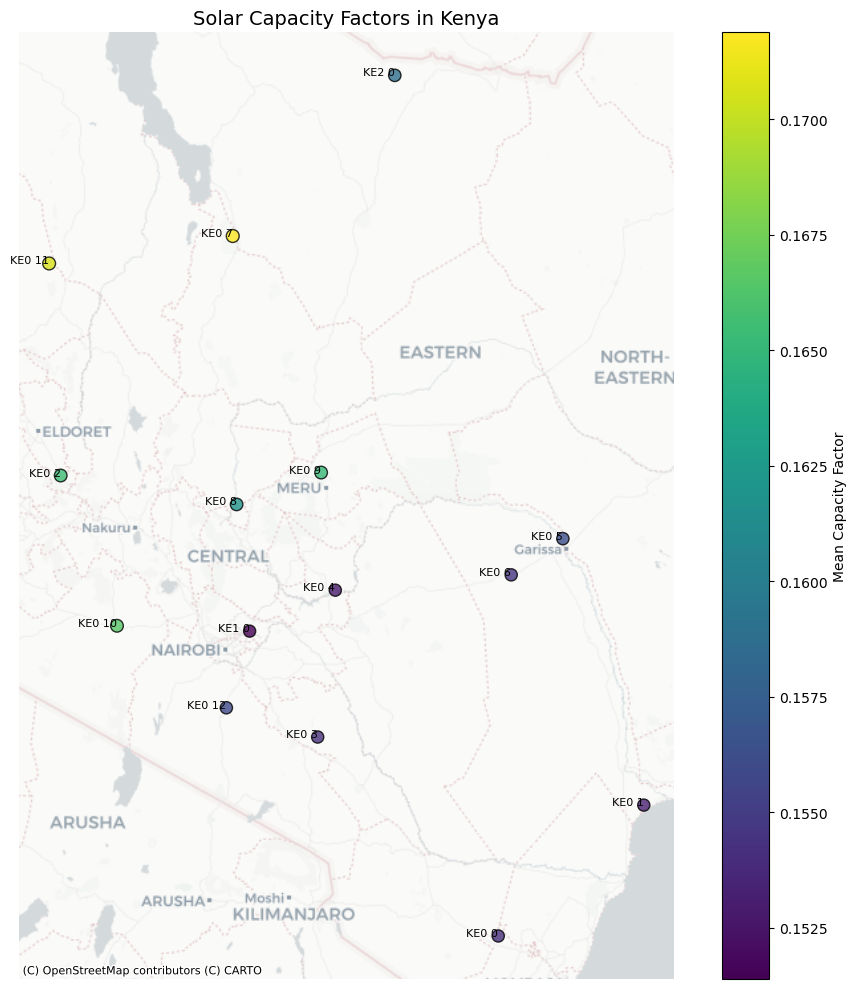

Generating Spatial Map for onwind...


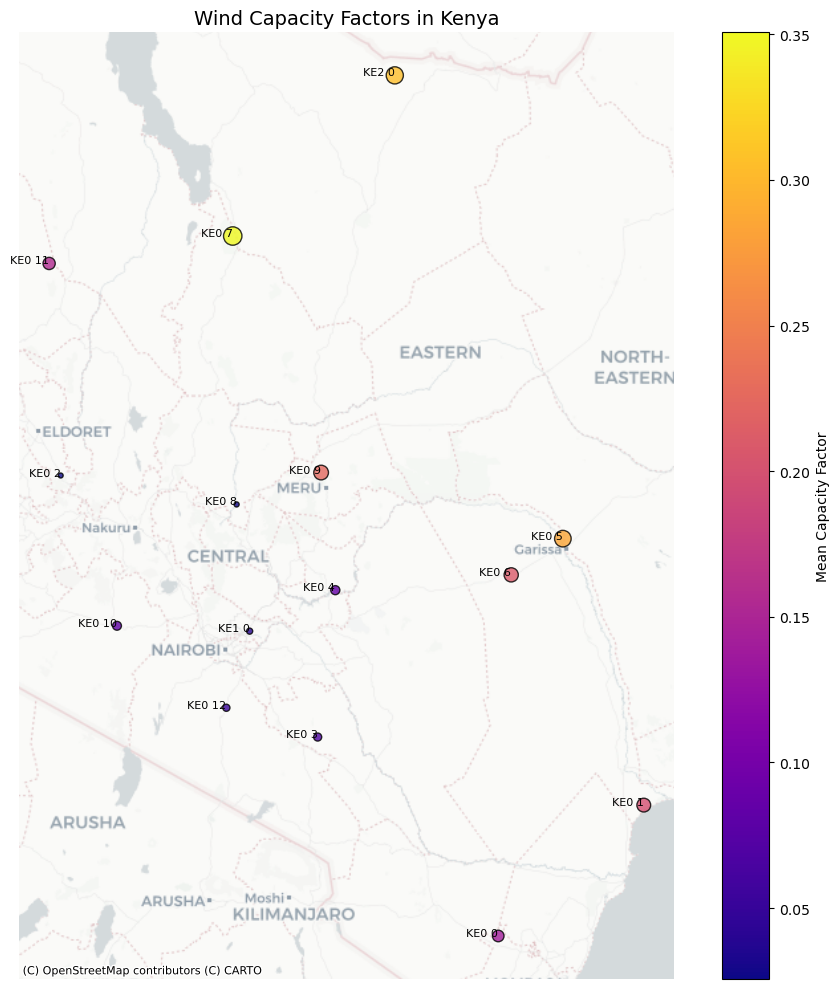

Generating Ranked Bar Chart: Ranked Solar Nodes by Mean CF...


C:\Users\devsi\AppData\Local\Temp\ipykernel_23764\1135037745.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df.index, y=sorted_df['Mean_CF'], palette='mako')


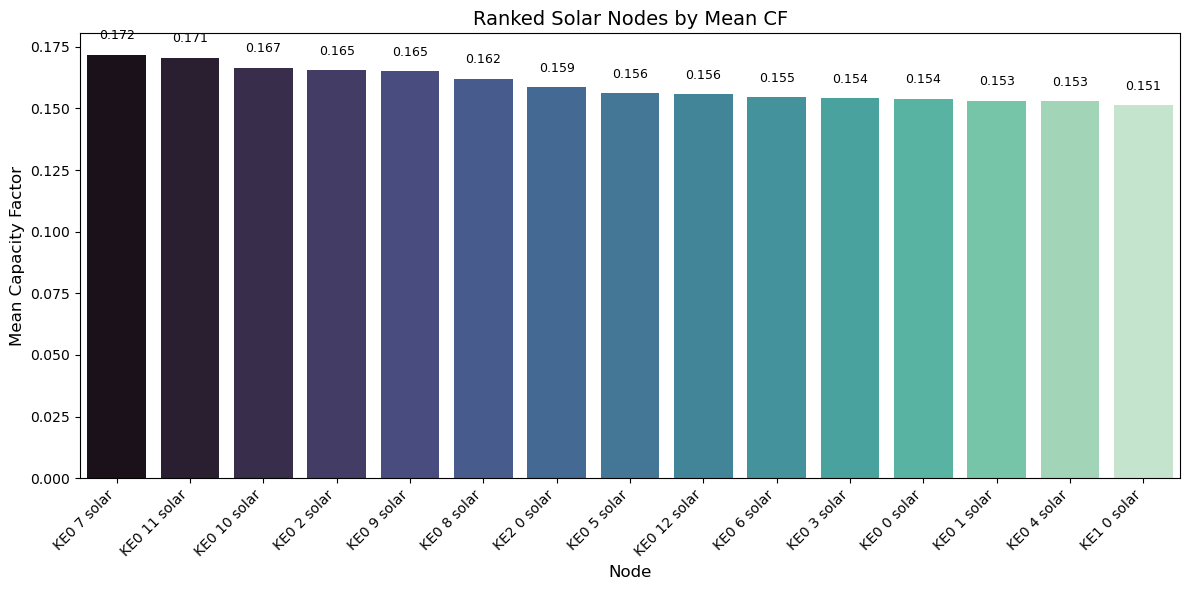

Generating Ranked Bar Chart: Ranked Wind Nodes by Mean CF...


C:\Users\devsi\AppData\Local\Temp\ipykernel_23764\1135037745.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df.index, y=sorted_df['Mean_CF'], palette='mako')


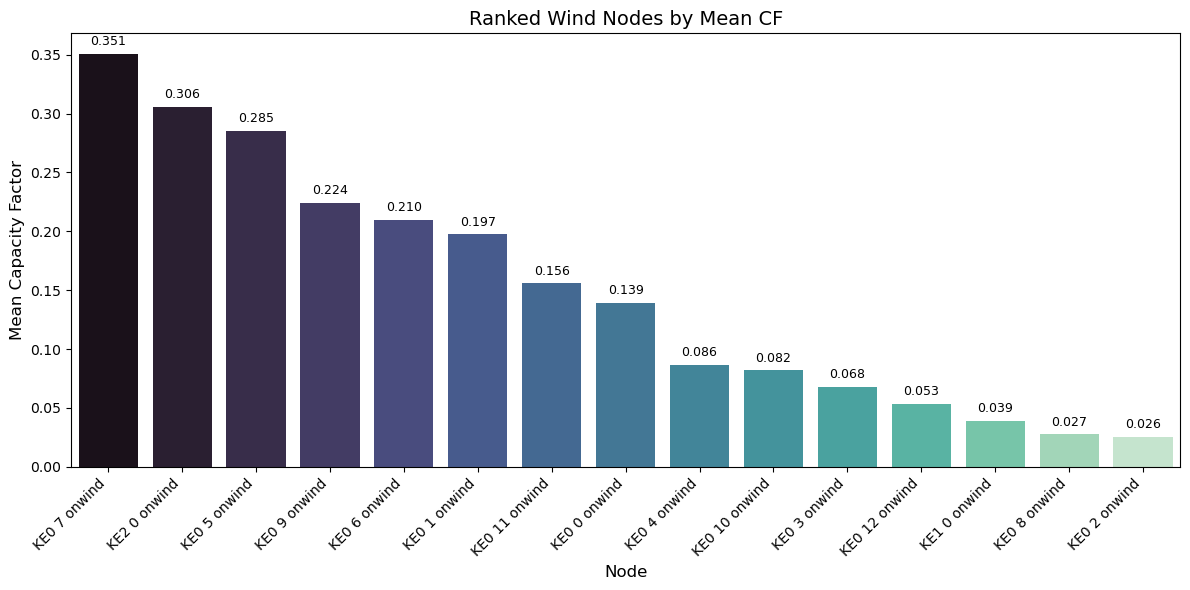

Generating Heatmap for KE0 7 solar...
  -> Converting integer index to 3-hourly DatetimeIndex for KE0 7 solar...


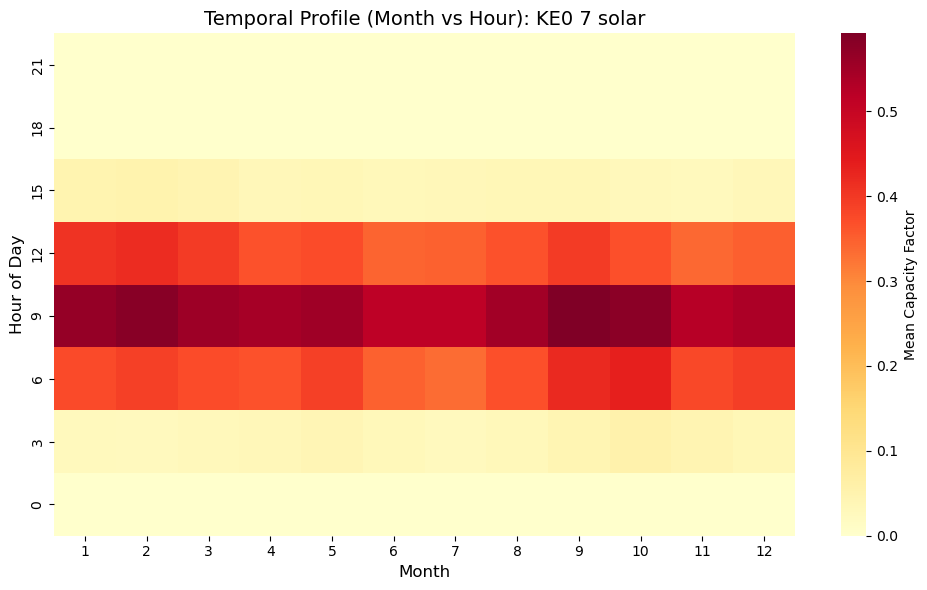

Generating Heatmap for KE0 7 onwind...
  -> Converting integer index to 3-hourly DatetimeIndex for KE0 7 onwind...


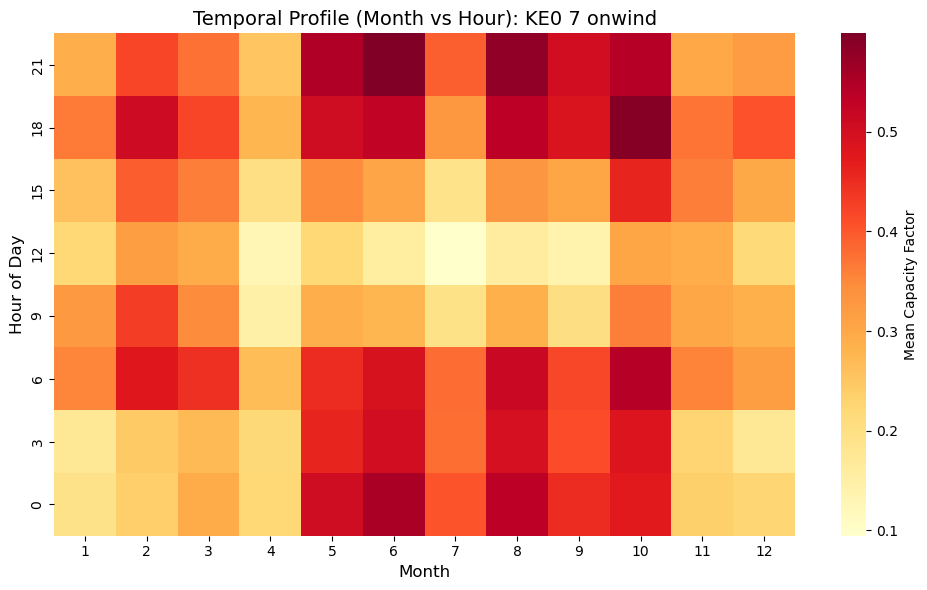

Generating Duration Curves: Solar Duration Curves...


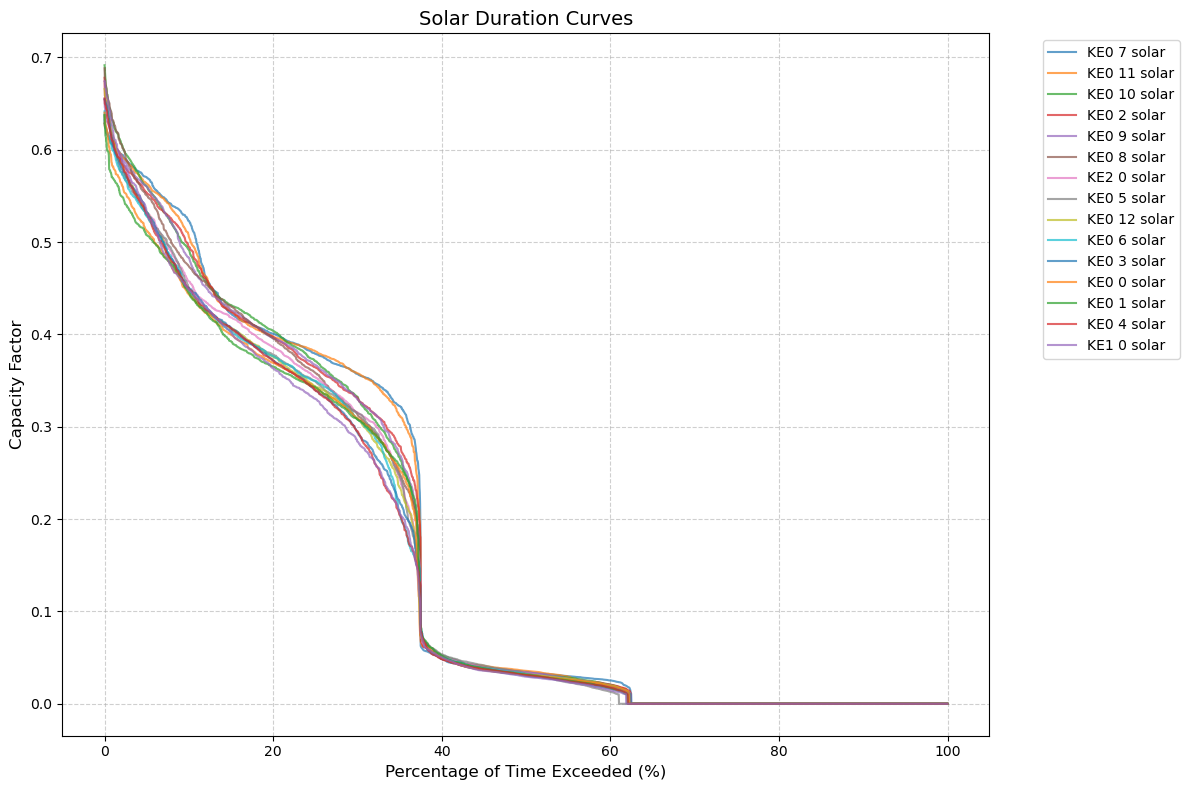

Generating Duration Curves: Wind Duration Curves...


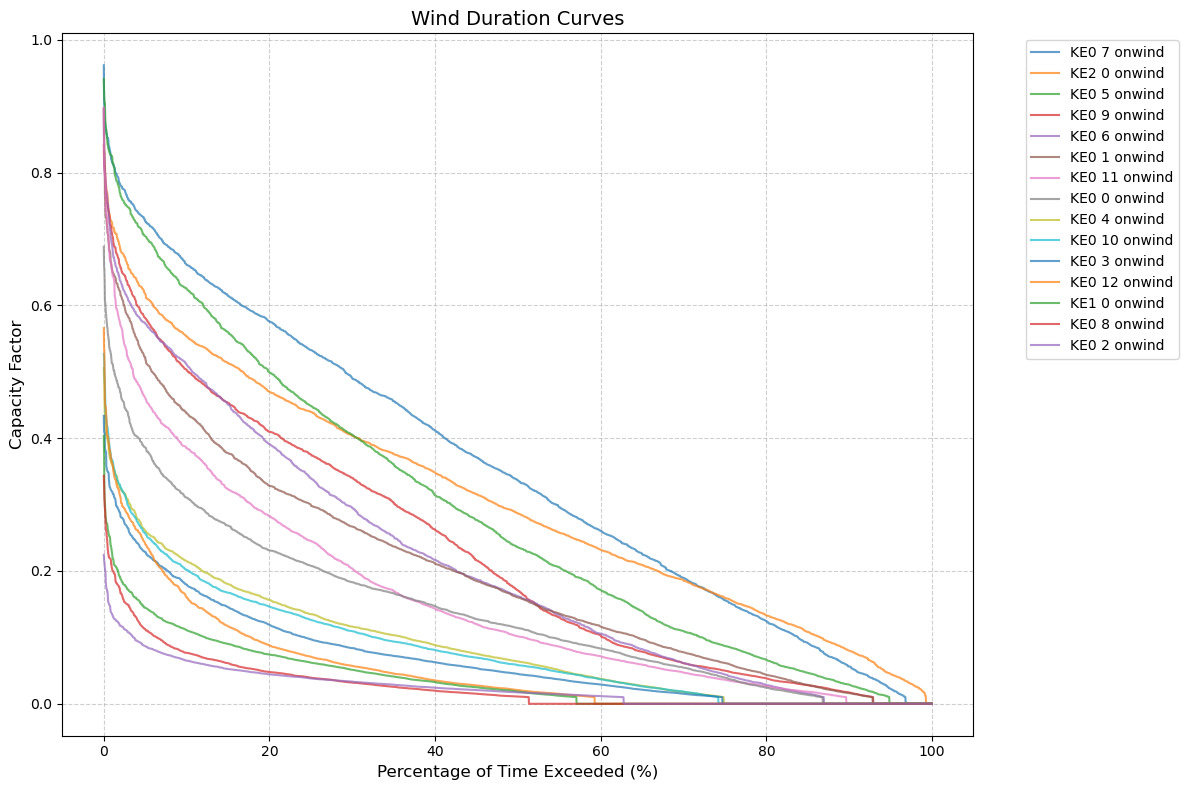

Generating Correlation Matrix: Solar Node Correlation Matrix...


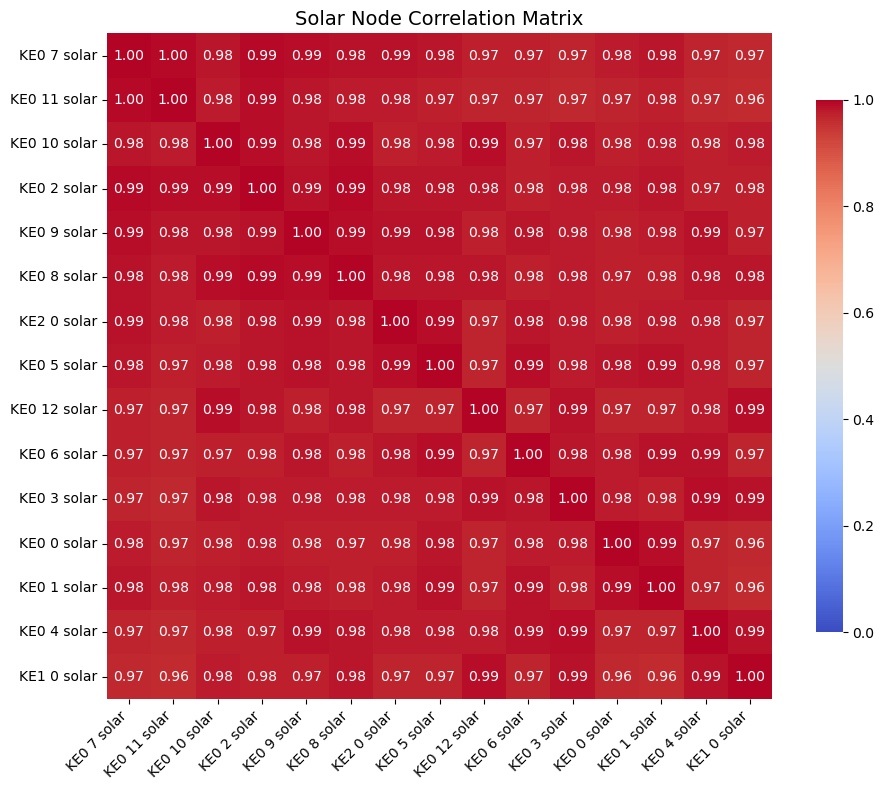

Generating Correlation Matrix: Wind Node Correlation Matrix...


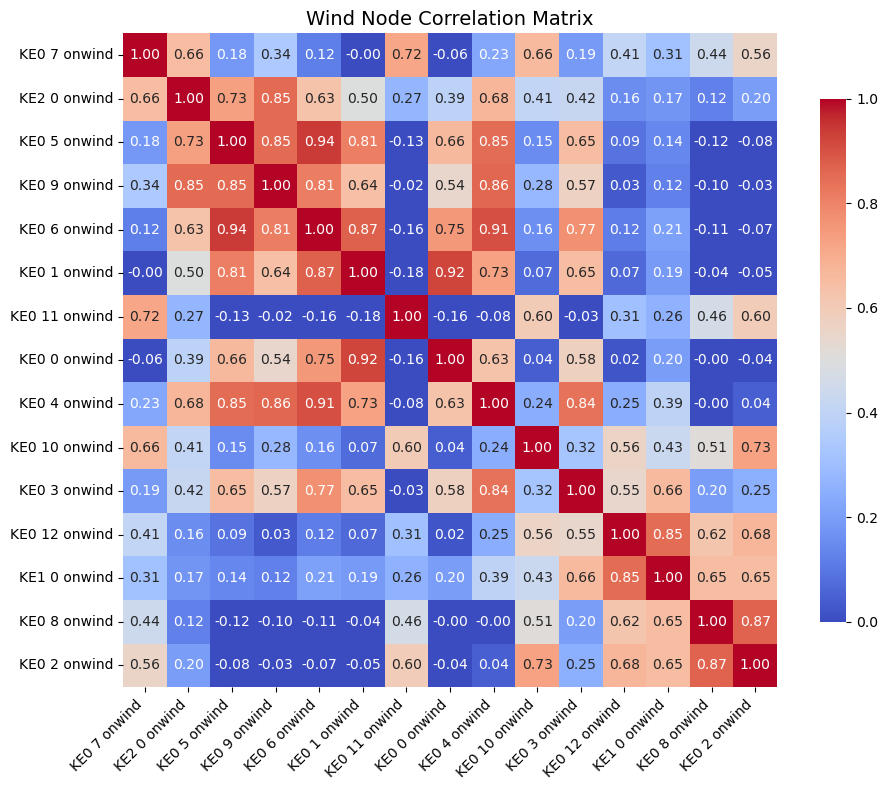

In [10]:

def generate_all_visuals(analysis_results, raw_df, csv_dir='./Network_CSV'):
    buses_df = load_spatial_data(csv_dir)
    
    # 1. Spatial Maps
    plot_spatial_map(analysis_results['solar_stats'], buses_df, "Solar Capacity Factors in Kenya", 'solar')
    plot_spatial_map(analysis_results['wind_stats'], buses_df, "Wind Capacity Factors in Kenya", 'onwind')
    
    # 2. Ranked Bar Charts
    plot_ranked_bar_chart(analysis_results['solar_stats'], "Ranked Solar Nodes by Mean CF")
    plot_ranked_bar_chart(analysis_results['wind_stats'], "Ranked Wind Nodes by Mean CF")
    
    # 3. Temporal Heatmaps (Example for the top node of each tech)
    top_solar_node = analysis_results['solar_stats'].index[0]
    top_wind_node = analysis_results['wind_stats'].index[0]
    plot_temporal_heatmap(raw_df, top_solar_node)
    plot_temporal_heatmap(raw_df, top_wind_node)
    
    # 4. Duration Curves
    solar_cols = analysis_results['solar_stats'].index.tolist()
    wind_cols = analysis_results['wind_stats'].index.tolist()
    plot_duration_curves(raw_df, solar_cols, "Solar Duration Curves")
    plot_duration_curves(raw_df, wind_cols, "Wind Duration Curves")
    
    # 5. Correlation Matrices
    plot_correlation_matrix(raw_df, solar_cols, "Solar Node Correlation Matrix")
    plot_correlation_matrix(raw_df, wind_cols, "Wind Node Correlation Matrix")

generate_all_visuals(analysis_results, df_cf)

Top 2 Solar Nodes: ['KE0 7 solar', 'KE0 11 solar']
Top 2 Wind Nodes:  ['KE0 7 onwind', 'KE2 0 onwind']
  -> Converting integer index to 3-hourly DatetimeIndex...


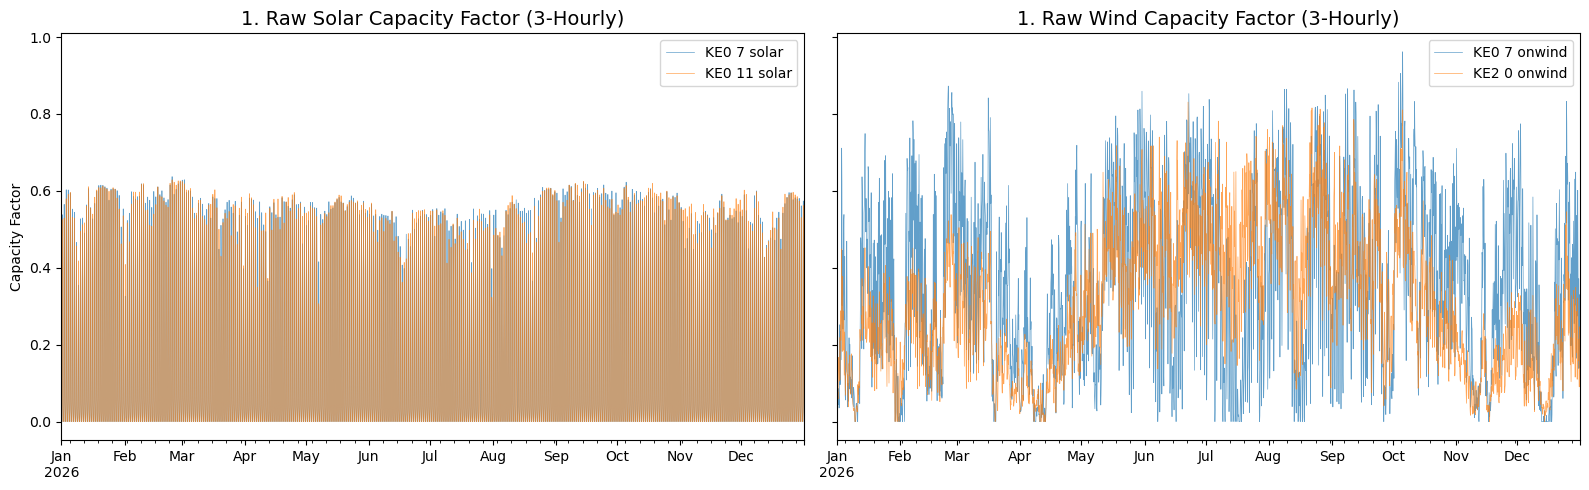

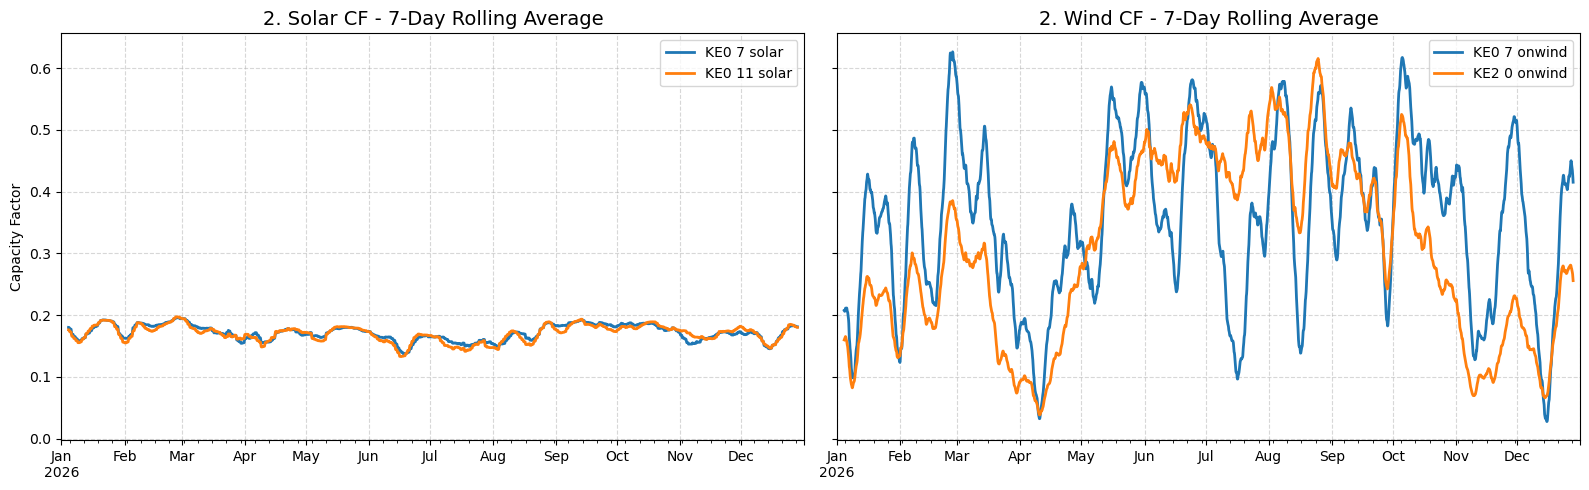

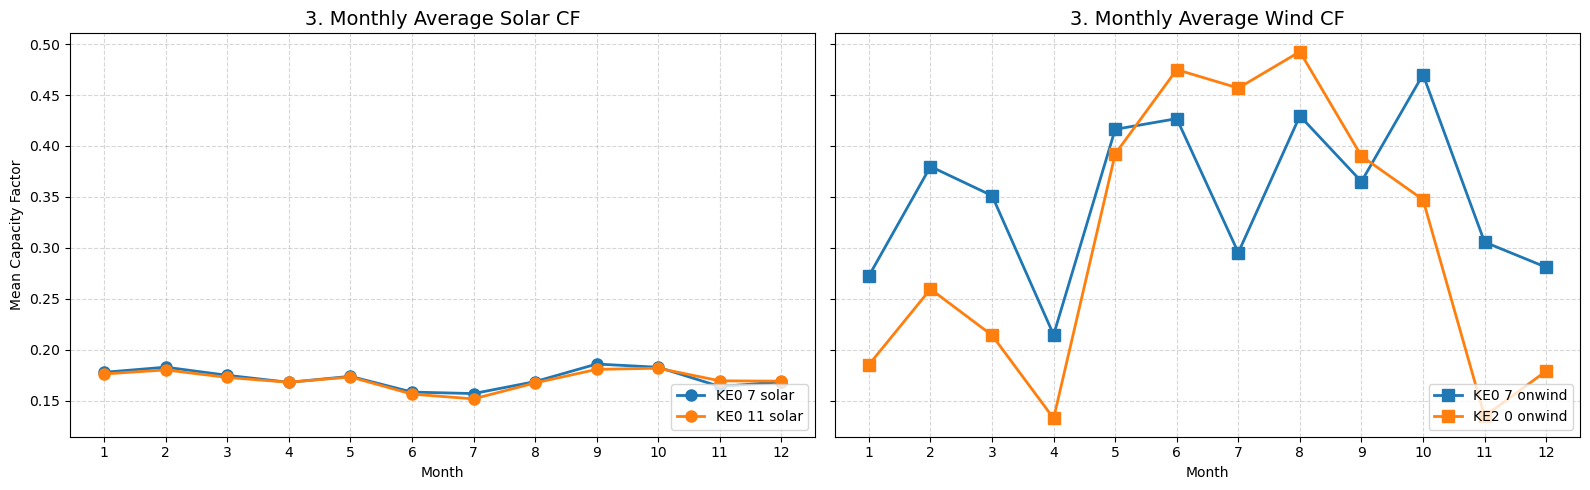

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_top_nodes_timeseries(raw_df, analysis_results):
    """
    Plots raw, rolling, and monthly time-series for the top 2 solar and wind nodes.
    Includes a safeguard to convert integer indices to DatetimeIndex.
    """
    # 1. Identify the Top 2 Nodes for each technology (based on Mean CF)
    top_solar = analysis_results['solar_stats'].head(2).index.tolist()
    top_wind = analysis_results['wind_stats'].head(2).index.tolist()
    
    print(f"Top 2 Solar Nodes: {top_solar}")
    print(f"Top 2 Wind Nodes:  {top_wind}")

    # Extract data for just these nodes
    df_top = raw_df[top_solar + top_wind].copy()
    
    # --- THE FIX ---
    # Check if the index is a proper DatetimeIndex. If not, forcefully reconstruct it.
    if not isinstance(df_top.index, pd.DatetimeIndex):
        print("  -> Converting integer index to 3-hourly DatetimeIndex...")
        df_top.index = pd.date_range(start='2026-01-01', periods=len(df_top), freq='3h')
    # ---------------
    
    # ---------------------------------------------------------
    # Plot 1: Simple Raw Data Time-Series
    # ---------------------------------------------------------
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    df_top[top_solar].plot(ax=ax1, alpha=0.7, linewidth=0.5)
    ax1.set_title("1. Raw Solar Capacity Factor (3-Hourly)", fontsize=14)
    ax1.set_ylabel("Capacity Factor")
    ax1.legend(loc='upper right')
    
    df_top[top_wind].plot(ax=ax2, alpha=0.7, linewidth=0.5)
    ax2.set_title("1. Raw Wind Capacity Factor (3-Hourly)", fontsize=14)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot 2: Rolling Averaged Time-Series (7-Day Window)
    # ---------------------------------------------------------
    # Since data is 3-hourly, there are 8 steps per day. 
    # A 7-day rolling window is 7 * 8 = 56 steps.
    window_size = 56 
    df_rolling = df_top.rolling(window=window_size, center=True).mean()

    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    df_rolling[top_solar].plot(ax=ax3, linewidth=2)
    ax3.set_title(f"2. Solar CF - 7-Day Rolling Average", fontsize=14)
    ax3.set_ylabel("Capacity Factor")
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle='--', alpha=0.5)
    
    df_rolling[top_wind].plot(ax=ax4, linewidth=2)
    ax4.set_title(f"2. Wind CF - 7-Day Rolling Average", fontsize=14)
    ax4.legend(loc='upper right')
    ax4.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot 3: Monthly Averaged Capacity Factors
    # ---------------------------------------------------------
    df_monthly = df_top.groupby(df_top.index.month).mean()
    
    fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    # Using markers to make the monthly points distinct
    df_monthly[top_solar].plot(ax=ax5, marker='o', linewidth=2, markersize=8)
    ax5.set_title("3. Monthly Average Solar CF", fontsize=14)
    ax5.set_ylabel("Mean Capacity Factor")
    ax5.set_xlabel("Month")
    ax5.set_xticks(range(1, 13)) # Force x-axis to show months 1-12
    ax5.grid(True, linestyle='--', alpha=0.5)
    ax5.legend(loc='lower right') # Usually better at the bottom for these
    
    df_monthly[top_wind].plot(ax=ax6, marker='s', linewidth=2, markersize=8)
    ax6.set_title("3. Monthly Average Wind CF", fontsize=14)
    ax6.set_xlabel("Month")
    ax6.set_xticks(range(1, 13))
    ax6.grid(True, linestyle='--', alpha=0.5)
    ax6.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_top_nodes_timeseries(df_cf, analysis_results)